In [2]:
import pandas as pd
import numpy as np
import io
from ipywidgets import FileUpload
from IPython.display import display

In [3]:

from google.colab import files
uploaded = files.upload()
import io
df = pd.read_csv(io.BytesIO(uploaded[list(uploaded.keys())[0]]))

# Basic overview
print("✅ Data loaded successfully!\n")
print("🧾 Shape:", df.shape)
print("\n📄 Columns:\n", df.columns.tolist())
print("\n🔍 Sample Data:")
df.head()

Saving hiPatterns.csv to hiPatterns.csv
✅ Data loaded successfully!

🧾 Shape: (241018, 11)

📄 Columns:
 ['date', 'time', 'transaction_id', 'sender_id', 'receiver_id', 'amount', 'currency', 'converted_amount', 'converted_currency', 'transaction_type', 'flag']

🔍 Sample Data:


,date,time,transaction_id,sender_id,receiver_id,amount,currency,converted_amount,converted_currency,transaction_type,flag
0,2022-08-09 05:14:00,952.0,8139F54E0,111632,8062C56E0,5331.44,US Dollar,5331.44,US Dollar,ACH,1
1,2022-08-13 13:09:00,111632.0,8062C56E0,8456,81363F620,5602.59,US Dollar,5602.59,US Dollar,ACH,1
2,2022-08-15 07:40:00,118693.0,823D5EB90,13729,801CF2E60,1400.54,US Dollar,1400.54,US Dollar,ACH,1
3,2022-08-15 14:19:00,13729.0,801CF2E60,123621,81A7090F0,1467.94,US Dollar,1467.94,US Dollar,ACH,1
4,2022-08-13 12:40:00,24750.0,81363F410,213834,808757B00,16898.29,US Dollar,16898.29,US Dollar,ACH,1


In [ ]:
summary = pd.DataFrame({
    'Column': df.columns,
    'Null %': df.isnull().mean().round(4) * 100,
    'Unique %': df.nunique() / len(df) * 100,
    'Type': [
        'Binary' if len(df[col].unique()) == 2 else
        'Categorical' if df[col].dtype == 'object' or len(df[col].unique()) < 20 else
        'Numeric'
        for col in df.columns
    ]
})

# Display summary
print("🛠️ COLUMN RATIO SUMMARY:")
display(summary)



🛠️ COLUMN RATIO SUMMARY:


,Column,Null %,Unique %,Type
date,date,0.0,100.00,Categorical
time,time,0.0,100.00,Numeric
transaction_id,transaction_id,0.0,100.00,Categorical
sender_id,sender_id,0.0,95.00,Numeric
receiver_id,receiver_id,0.0,100.00,Categorical
amount,amount,0.0,99.79,Numeric
currency,currency,0.0,0.06,Categorical
converted_amount,converted_amount,0.0,99.78,Numeric
converted_currency,converted_currency,0.0,0.06,Categorical
transaction_type,transaction_type,0.0,0.06,Categorical


In [ ]:
from datetime import datetime

In [ ]:
#  STEP 3: FEATURE DERIVATION

exchange_rates_to_inr = {
    'US Dollar': 83.0,
    'Euro': 90.0,
    'British Pound': 105.0,
    'Canadian Dollar': 61.0,
    'INR': 1.0,
    'Yen': 0.56
}

df['amount_inr'] = df.apply(
    lambda row: round(row['amount'] * exchange_rates_to_inr.get(row['currency'], 1.0), 2),
    axis=1
)

# ---- 2. Parse date column ----
df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce')


df['hour'] = df['date_parsed'].dt.hour
df['day_of_week'] = df['date_parsed'].dt.dayofweek  # Monday=0
df['month'] = df['date_parsed'].dt.month
df['date_india_format'] = df['date_parsed'].dt.strftime('%d-%m-%Y')


df['log_amount_inr'] = np.log1p(df['amount_inr'])


print("🧪 Derived Features:")
display(df[['amount', 'currency', 'amount_inr', 'hour', 'day_of_week', 'month', 'log_amount_inr']].head())


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

<Figure size 1200x600 with 0 Axes>

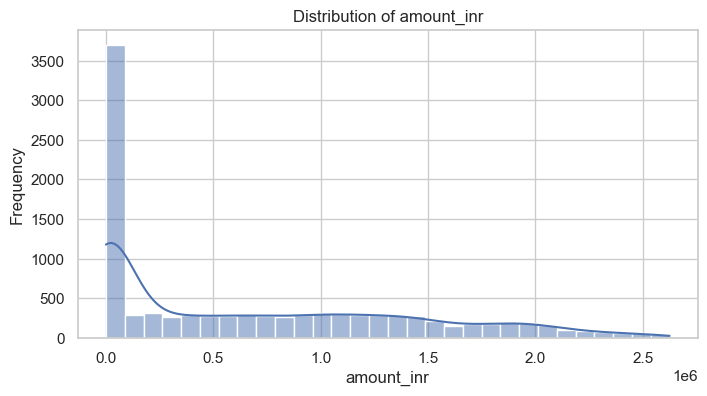

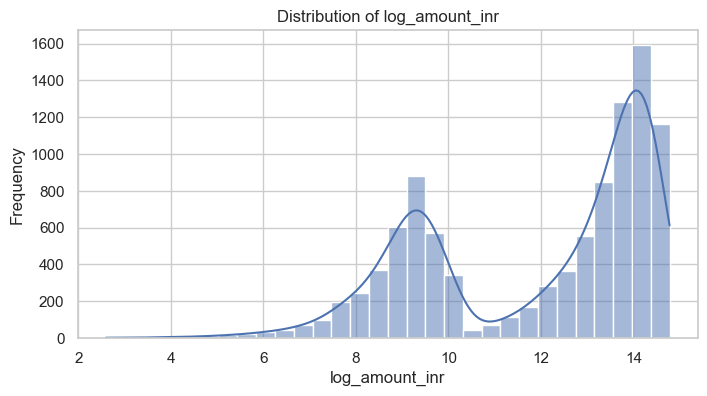

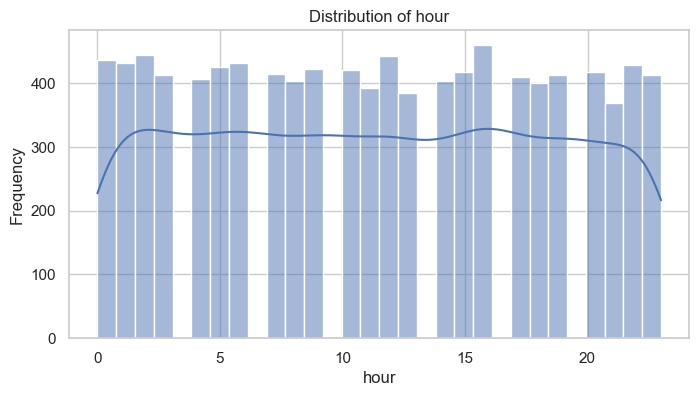

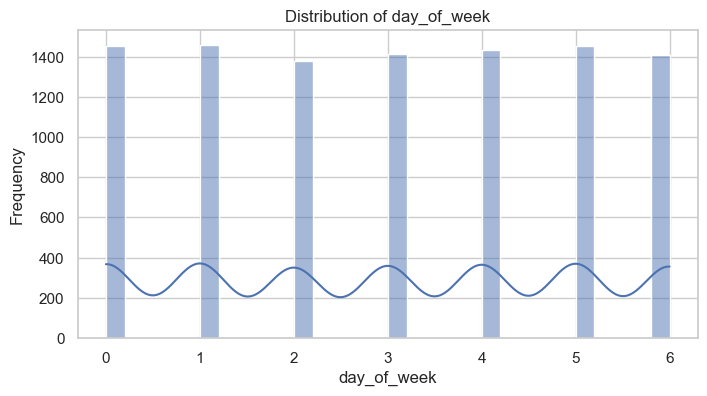

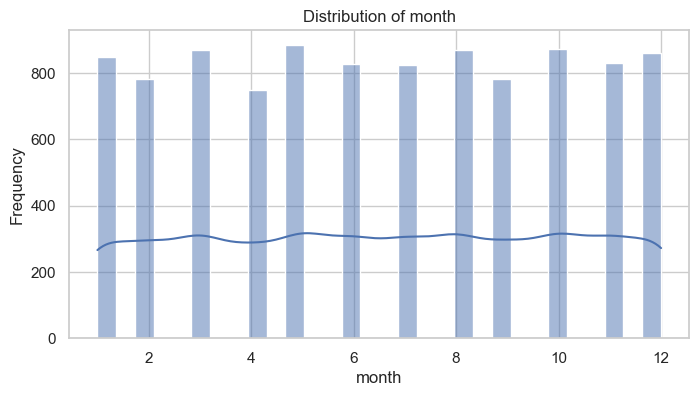

In [ ]:
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))


numeric_cols = ['amount_inr', 'log_amount_inr', 'hour', 'day_of_week', 'month']
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()



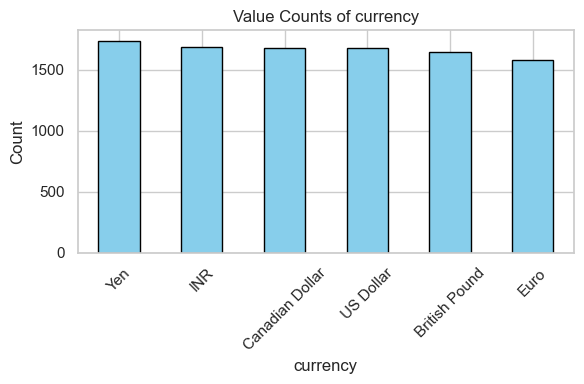

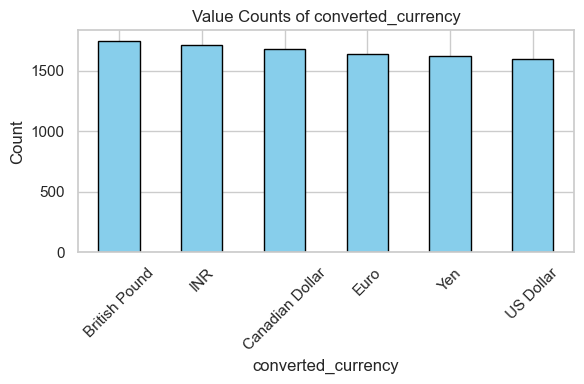

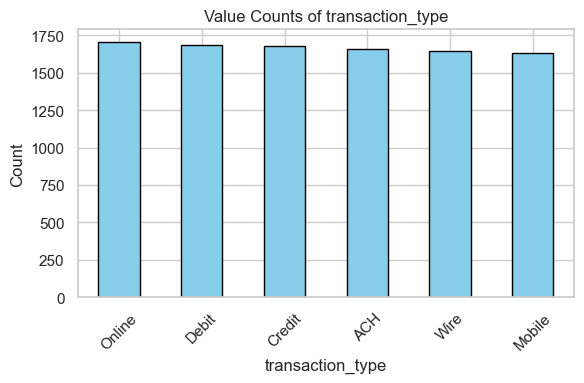

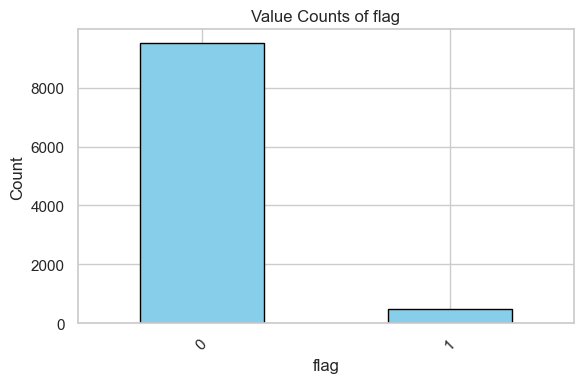

In [ ]:

categorical_cols = ['currency', 'converted_currency', 'transaction_type', 'flag']
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    df[col].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title(f"Value Counts of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

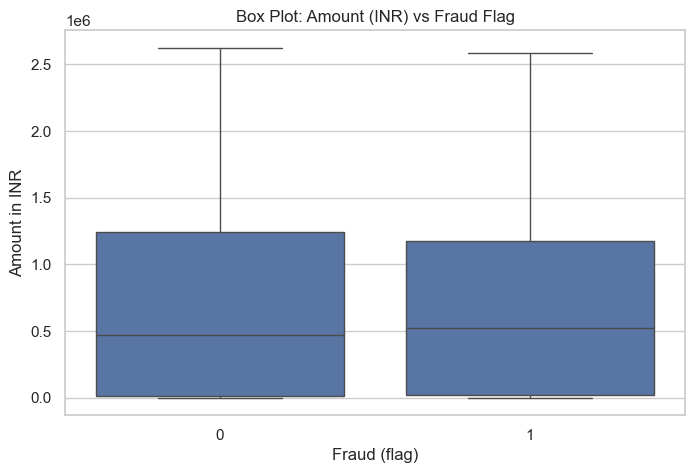

In [ ]:

plt.figure(figsize=(8, 5))
sns.boxplot(x='flag', y='amount_inr', d=df)
plt.title("Box Plot: Amount (INR) vs Fraud Flag")
plt.xlabel("Fraud (flag)")
plt.ylabel("Amount in INR")
plt.show()

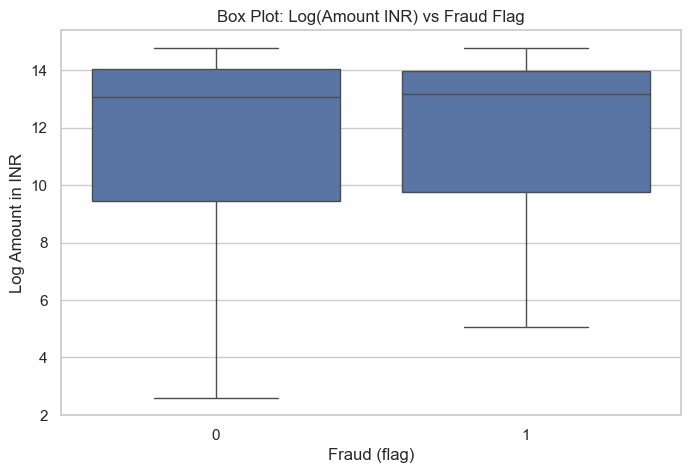

In [ ]:

plt.figure(figsize=(8, 5))
sns.boxplot(x='flag', y='log_amount_inr', d=df)
plt.title("Box Plot: Log(Amount INR) vs Fraud Flag")
plt.xlabel("Fraud (flag)")
plt.ylabel("Log Amount in INR")
plt.show()

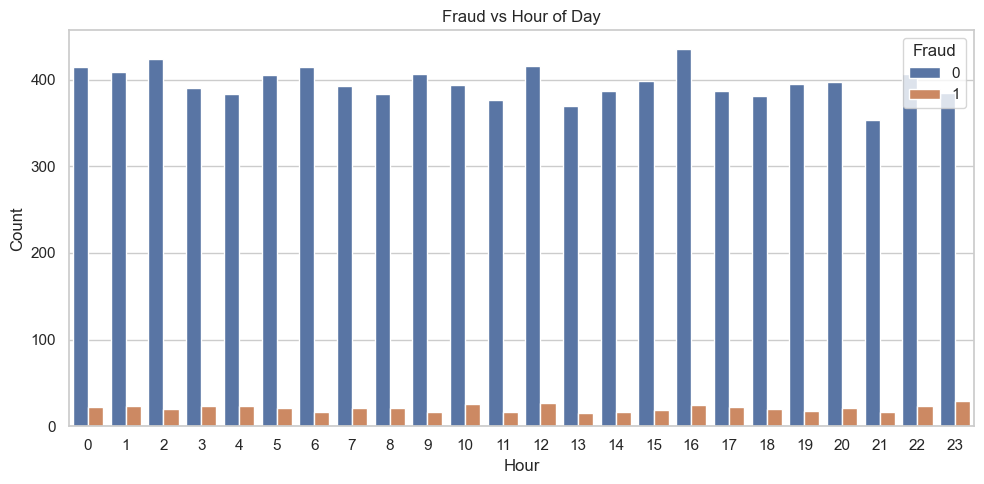

In [ ]:

plt.figure(figsize=(10, 5))
sns.countplot(x='hour', hue='flag', d=df)
plt.title("Fraud vs Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.legend(title="Fraud")
plt.tight_layout()
plt.show()

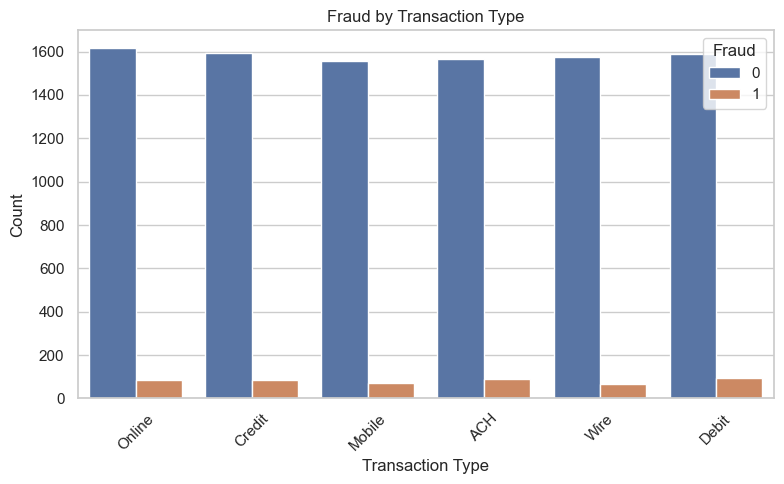

In [ ]:

plt.figure(figsize=(8, 5))
sns.countplot(x='transaction_type', hue='flag', d=df)
plt.title("Fraud by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.legend(title="Fraud")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

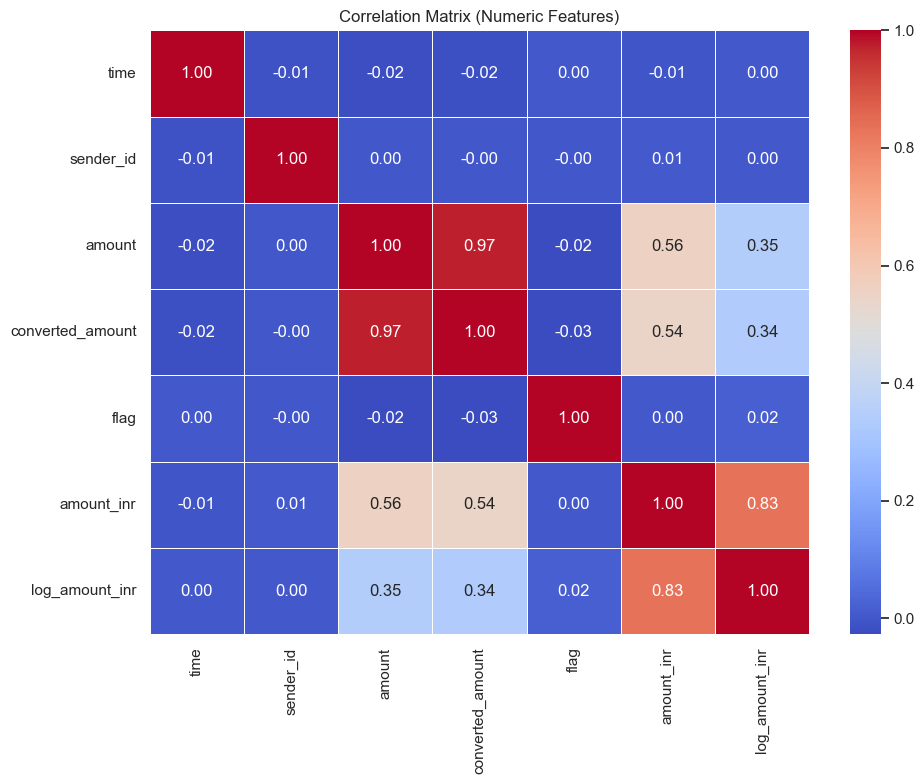

In [ ]:

numeric_features = df.select_dtypes(include=['float64', 'int64'])


corr_matrix = numeric_features.corr()

# ---- 3. Plot heatmap ----
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.show()

In [ ]:
df.to_csv("cleaned_aml_dset.csv", index=False)
